In [18]:
import datetime
import numpy as np
import pandas as pd
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
def load_data(battery):
  mat = loadmat('E:/' + battery + '.mat')
  print('Total data in dataset: ', len(mat[battery][0, 0]['cycle'][0]))
  counter = 0
  dataset = []
  capacity_data = []

  for i in range(len(mat[battery][0, 0]['cycle'][0])):
    row = mat[battery][0, 0]['cycle'][0, i]
    if row['type'][0] == 'discharge':
      ambient_temperature = row['ambient_temperature'][0][0]
      date_time = datetime.datetime(int(row['time'][0][0]),
                               int(row['time'][0][1]),
                               int(row['time'][0][2]),
                               int(row['time'][0][3]),
                               int(row['time'][0][4])) + datetime.timedelta(seconds=int(row['time'][0][5]))
      data = row['data']
      capacity = data[0][0]['Capacity'][0][0]
      for j in range(len(data[0][0]['Voltage_measured'][0])):
        voltage_measured = data[0][0]['Voltage_measured'][0][j]
        current_measured = data[0][0]['Current_measured'][0][j]
        temperature_measured = data[0][0]['Temperature_measured'][0][j]
        current_load = data[0][0]['Current_load'][0][j]
        voltage_load = data[0][0]['Voltage_load'][0][j]
        time = data[0][0]['Time'][0][j]
        dataset.append([counter + 1, ambient_temperature, date_time, capacity,
                        voltage_measured, current_measured,
                        temperature_measured, current_load,
                        voltage_load, time])
      capacity_data.append([counter + 1, ambient_temperature, date_time, capacity])
      counter = counter + 1
  print(dataset[0])
  return [pd.DataFrame(data=dataset,
                       columns=['cycle', 'ambient_temperature', 'datetime',
                                'capacity', 'voltage_measured',
                                'current_measured', 'temperature_measured',
                                'current_load', 'voltage_load', 'time']),
          pd.DataFrame(data=capacity_data,
                       columns=['cycle', 'ambient_temperature', 'datetime',
                                'capacity'])]

In [20]:
dataset1, capacity1 = load_data('B0005')
dataset2, capacity2 = load_data('B0006')
dataset3, capacity3 = load_data('B0007')
dataset = pd.concat([dataset1, dataset2,dataset3], axis=0)
capacity = pd.concat([capacity1, capacity2,capacity3], axis=0)
capacity = capacity.reset_index(drop=True)
dataset = dataset.reset_index(drop=True)
pd.set_option('display.max_columns', 10)
print(dataset.head())
dataset.describe()

Total data in dataset:  616
[1, 24, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.8564874208181574, 4.191491807505295, -0.004901589207462691, 24.330033885570543, -0.0006, 0.0, 0.0]
Total data in dataset:  616
[1, 24, datetime.datetime(2008, 4, 2, 15, 25, 41), 2.035337591005598, 4.179799607333447, -0.0023663271409738672, 24.277567510331888, -0.0006, 0.0, 0.0]
Total data in dataset:  616
[1, 24, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.89105229539079, 4.199359521791473, -0.0018658918833680202, 23.93704394613529, -0.0004, 0.0, 0.0]
   cycle  ambient_temperature            datetime  capacity  voltage_measured  \
0      1                   24 2008-04-02 15:25:41  1.856487          4.191492   
1      1                   24 2008-04-02 15:25:41  1.856487          4.190749   
2      1                   24 2008-04-02 15:25:41  1.856487          3.974871   
3      1                   24 2008-04-02 15:25:41  1.856487          3.951717   
4      1                   24 2008-04-02 15:25:41  1.8564

,cycle,ambient_temperature,datetime,capacity,voltage_measured,current_measured,temperature_measured,current_load,voltage_load,time
count,150855.000000,150855.0,150855,150855.000000,150855.000000,150855.000000,150855.000000,150855.000000,150855.000000,150855.000000
mean,88.125942,24.0,2008-05-07 01:58:43.570826496,1.572658,3.496295,-1.830176,32.678481,1.380269,2.356804,1546.208924
min,1.000000,24.0,2008-04-02 15:25:41,1.153818,1.737030,-2.029098,22.969923,-2.000000,0.000000,0.000000
25%,50.000000,24.0,2008-04-29 22:00:04,1.421263,3.376218,-2.011829,29.799346,1.998000,2.400000,768.563000
50%,88.000000,24.0,2008-05-07 21:56:09,1.548874,3.501689,-2.009524,32.673429,1.998800,2.550000,1537.031000
75%,127.000000,24.0,2008-05-18 03:05:19,1.750291,3.654211,-1.989517,35.764639,2.000000,2.710000,2305.984000
max,168.000000,24.0,2008-05-27 20:45:42,2.035338,4.233325,0.008809,42.332522,2.000000,4.249000,3690.234000
std,45.699384,0.0,NaN,0.197633,0.252063,0.563430,4.051582,1.320856,0.752715,906.634285


In [21]:
attrib=['cycle', 'datetime', 'capacity']
dis_ele = capacity[attrib]
C = dis_ele['capacity'][0]
for i in range(len(dis_ele)):
    dis_ele['SoH']=(dis_ele['capacity'])/C
print(dis_ele)

C = dataset['capacity'][0]
soh = []
for i in range(len(dataset)):
  soh.append([dataset['capacity'][i] / C])
soh = pd.DataFrame(data=soh, columns=['SoH'])

attribs=['capacity', 'voltage_measured', 'current_measured',
         'temperature_measured', 'current_load', 'voltage_load', 'time']
train_dataset = dataset[attribs]
sc = MinMaxScaler(feature_range=(0,1))
train_dataset = sc.fit_transform(train_dataset)
print(train_dataset.shape)
print(soh.shape)

     cycle            datetime  capacity       SoH
0        1 2008-04-02 15:25:41  1.856487  1.000000
1        2 2008-04-02 19:43:48  1.846327  0.994527
2        3 2008-04-03 00:01:06  1.835349  0.988614
3        4 2008-04-03 04:16:37  1.835263  0.988567
4        5 2008-04-03 08:33:25  1.834646  0.988235
..     ...                 ...       ...       ...
499    164 2008-05-26 10:44:38  1.406171  0.757437
500    165 2008-05-26 15:30:43  1.406336  0.757525
501    166 2008-05-26 20:21:04  1.400455  0.754358
502    167 2008-05-27 15:52:41  1.421787  0.765848
503    168 2008-05-27 20:45:42  1.432455  0.771594

[504 rows x 4 columns]
(150855, 7)
(150855, 1)


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_valid, Y_train, Y_valid = train_test_split(train_dataset, soh, test_size=0.2, random_state=0)
print('Train set shape', X_train.shape)
print('Validation set shape', X_valid.shape)

Train set shape (120684, 7)
Validation set shape (30171, 7)


In [23]:

X_train_series = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_valid_series = X_valid.reshape((X_valid.shape[0], X_valid.shape[1], 1))
print('Train set shape', X_train_series.shape)
print('Validation set shape', X_valid_series.shape)

Train set shape (120684, 7, 1)
Validation set shape (30171, 7, 1)


In [24]:
from tensorflow.keras.layers import Dense, Dropout, Flatten, LSTM, Bidirectional, Conv1D, MaxPooling1D, Multiply,Input
from tensorflow.keras.models import Model
window=2
inputs=Input(shape=(X_train_series.shape[1], X_train_series.shape[2]))
model=Conv1D(filters = 64, kernel_size = 3, activation = 'relu')(inputs)
model=MaxPooling1D(pool_size = window)(model)
model=Dropout(0.3)(model)
model=Bidirectional(LSTM(100, activation='relu'), name='bilstm')(model)
attention=Dense(200, activation='sigmoid', name='attention_vec')(model)
model=Multiply()([model, attention])
outputs = Dense(1, activation='relu')(model)
model = Model(inputs=inputs, outputs=outputs)
model.compile(loss='mse',optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 7, 1)]       0           []                               
                                                                                                  
 conv1d_1 (Conv1D)              (None, 5, 64)        256         ['input_2[0][0]']                
                                                                                                  
 max_pooling1d_1 (MaxPooling1D)  (None, 2, 64)       0           ['conv1d_1[0][0]']               
                                                                                                  
 dropout_1 (Dropout)            (None, 2, 64)        0           ['max_pooling1d_1[0][0]']        
                                                                                            

In [25]:
AM_CNN_lstm_history = model.fit(X_train_series, Y_train, validation_data=(X_valid_series, Y_valid), epochs=30, verbose=2)

Epoch 1/30
3772/3772 - 22s - loss: 0.0050 - accuracy: 0.0014 - val_loss: 0.0015 - val_accuracy: 0.0011 - 22s/epoch - 6ms/step
Epoch 2/30
3772/3772 - 18s - loss: 2.3247e-04 - accuracy: 0.0014 - val_loss: 0.0030 - val_accuracy: 0.0011 - 18s/epoch - 5ms/step
Epoch 3/30
3772/3772 - 18s - loss: 1.1079e-04 - accuracy: 0.0014 - val_loss: 0.0033 - val_accuracy: 0.0011 - 18s/epoch - 5ms/step
Epoch 4/30
3772/3772 - 18s - loss: 8.2256e-05 - accuracy: 0.0014 - val_loss: 0.0031 - val_accuracy: 0.0011 - 18s/epoch - 5ms/step
Epoch 5/30
3772/3772 - 19s - loss: 6.6218e-05 - accuracy: 0.0014 - val_loss: 0.0029 - val_accuracy: 0.0011 - 19s/epoch - 5ms/step
Epoch 6/30
3772/3772 - 18s - loss: 5.4882e-05 - accuracy: 0.0014 - val_loss: 0.0032 - val_accuracy: 0.0011 - 18s/epoch - 5ms/step
Epoch 7/30
3772/3772 - 17s - loss: 4.8229e-05 - accuracy: 0.0014 - val_loss: 0.0021 - val_accuracy: 0.0011 - 17s/epoch - 5ms/step
Epoch 8/30
3772/3772 - 18s - loss: 4.2339e-05 - accuracy: 0.0014 - val_loss: 0.0025 - val_accu

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> TESTING
Total data in dataset:  319
[1, 24, datetime.datetime(2008, 7, 7, 15, 15, 28), 1.8550045207910817, 4.188108651124536, 0.00013066734156636677, 23.8195202516044, 0.0006, 0.0, 0.0]
   cycle  ambient_temperature            datetime  capacity  voltage_measured  \
0      1                   24 2008-07-07 15:15:28  1.855005          4.188109   
1      1                   24 2008-07-07 15:15:28  1.855005          4.188196   
2      1                   24 2008-07-07 15:15:28  1.855005          3.977432   
3      1                   24 2008-07-07 15:15:28  1.855005          3.961974   
4      1                   24 2008-07-07 15:15:28  1.855005          3.949835   

   current_measured  temperature_measured  current_load  voltage_load    time  
0          0.000131             23.819520        0.0006         0.000   0.000  
1          0.001459             23.828807        0.0006         4.203   9.422  
2         -2.005672             23.84

<Figure size 1000x600 with 0 Axes>

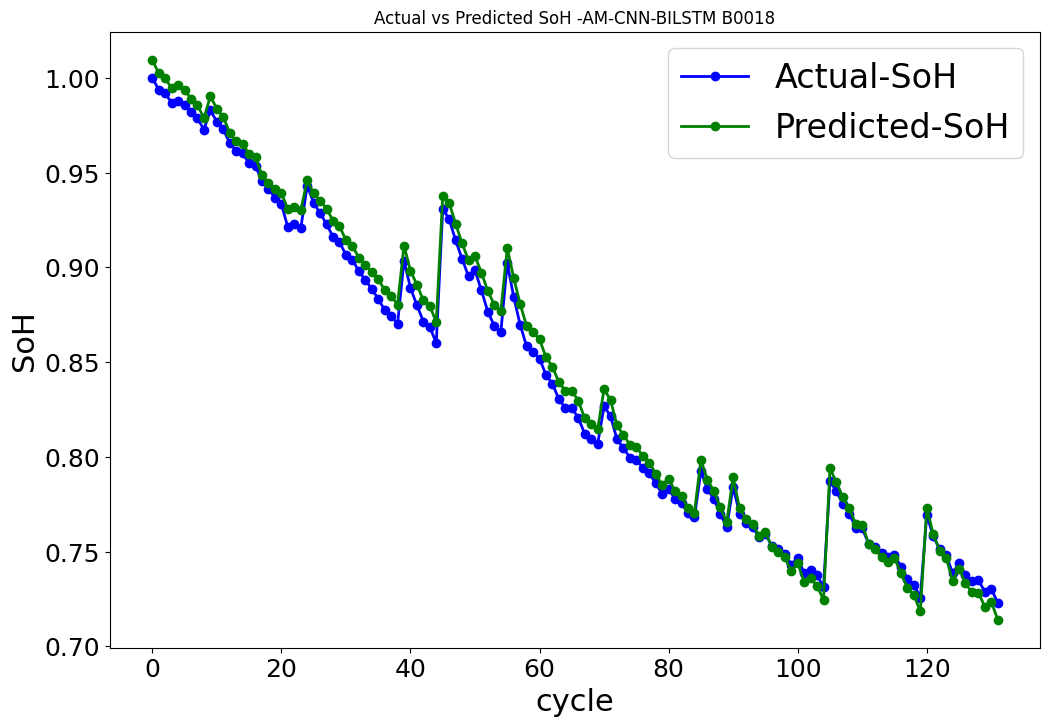

In [29]:
print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> TESTING")
dataset_val, capacity_val = load_data('B0018')
attrib=['cycle', 'datetime', 'capacity']
dis_ele = capacity_val[attrib]
C = dis_ele['capacity'][0]
for i in range(len(dis_ele)):
    dis_ele['SoH']=(dis_ele['capacity']) / C
print(dataset_val.head(5))
print(dis_ele.head(5))
attrib=['capacity', 'voltage_measured', 'current_measured',
        'temperature_measured', 'current_load', 'voltage_load', 'time']
soh_pred =  model.predict(sc.fit_transform(dataset_val[attrib]))
print(soh_pred.shape)
print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>.ACTUAL AND PREDICTED SOH")
C = dataset_val['capacity'][0]
soh = []
for i in range(len(dataset_val)):
  soh.append(dataset_val['capacity'][i] / C)
new_soh = dataset_val.loc[(dataset_val['cycle'] >= 1), ['cycle']]
new_soh['SoH'] =  soh
new_soh['NewSoH'] = soh_pred
new_soh = new_soh.groupby(['cycle']).mean().reset_index()
print(new_soh.head(10))
rms = np.sqrt(mean_squared_error(new_soh['SoH'], new_soh['NewSoH']))
print('Root Mean Square Error: ', rms)
# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((new_soh['SoH'] - new_soh['NewSoH']) / new_soh['SoH'])) * 100
print("Mean Absolute Percentage Error (MAPE):", mape)
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(new_soh['SoH'], new_soh['NewSoH'])
print("Mean Squared Error (MSE):", mse)
mae = mean_absolute_error(new_soh['SoH'], new_soh['NewSoH'])
print(f'Mean Absolute Error (MAE): {mae:.4f}')
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
# Tracer les valeurs réelles vs les valeurs prédites
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots(1, figsize=(12, 8))
plt.plot(new_soh['SoH'], color='blue', linewidth=2, label='Actual-SoH', marker='o')
plt.plot(new_soh['NewSoH'], color='green', linewidth=2, label='Predicted-SoH', marker='o')
ax.set_xlabel('cycle', fontsize=22)  # Taille de police de l'axe des abscisses
ax.set_ylabel('SoH', fontsize=22)       # Taille de police de l'axe des ordonnées
ax.set_title('Actual vs Predicted SoH -AM-CNN-BILSTM B0018')
ax.tick_params(axis='x', which='major', labelsize=18)  # Taille des hachures des axes des abscisses
ax.tick_params(axis='y', which='major', labelsize=18)  # Taille des hachures des axes des ordonnées
# Légende
plt.legend(fontsize=24)

plt.show()


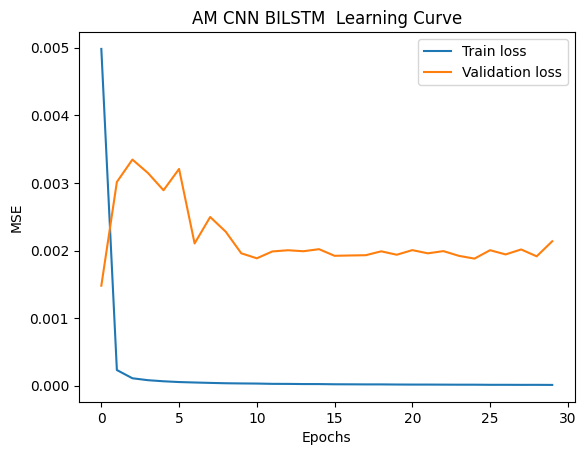

In [30]:
import matplotlib.pyplot as plt
plt.plot(AM_CNN_lstm_history.history['loss'], label='Train loss')
plt.plot(AM_CNN_lstm_history.history['val_loss'], label='Validation loss')
plt.legend(loc='best')
plt.title('AM CNN BILSTM  Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

In [31]:
model.save('AM CNN BILSTM18.h5')
# Chargement
from keras.models import load_model
model = load_model('AM CNN BILSTM18.h5')